
# 第五章

`原著: Cam Davidson-Pilon`

`Python 3 / PyMC3 移植: Max Margenot (@clean_utensils), Thomas Wiecki (@twiecki), Quantopian`

`PyMC (最新) 移植: Kurisu Chan (@miemiekurisu)`

`中文翻译、现代 PyMC (6.x) 适配与内容增补: 本 fork 维护者`

____

### 你是宁愿失去一条胳膊,还是一条腿?

**本章的现代 PyMC 修复说明**:原书里有一处用到了 `ax._get_lines.prop_cycler`
这个 matplotlib 的私有内部属性来获取"下一个默认配色",这个属性在现代
matplotlib 中已经被移除,我们换成了官方支持的等价写法
`ax._get_lines.get_next_color()`。另外,本章后半段"观测暗物质世界"
(Dark Worlds)这个案例用到的 `pm.sample(..., init='advi', n_init=50000, ...)`
在没有 C 编译器、只能用 NUMBA 后端跑的沙箱环境下会非常慢,我们把
`n_init`/`samples`/`chains` 都调小了,让示例能在合理时间内真正跑完并验证,
同时在文中说明了原书使用的是规模大得多的参数,得到的结果会更精细。



统计学家往往是一群"扫兴"的人。他们不太考虑自己赢了多少,只关心自己损失了多少。事实上,他们把"赢"看作*负的损失*。但有意思的地方在于,*他们是怎么衡量损失的*。

举个例子,考虑下面这个情形:

> 一位气象学家正在预测一场可能来袭的飓风会不会击中他所在的城市。他以 95% 的信心估计,飓风*不会*击中的概率在 99% 到 100% 之间。他对自己的精确度非常满意,并建议市政府没有必要进行大规模疏散。不幸的是,飓风最终还是击中了城市,城市被淹。

这个刻意设计的例子说明了,单纯用准确度这一个指标来衡量结果存在缺陷。使用一个只强调"估计准确性"的指标,虽然看起来很有吸引力、很*客观*,却忽略了我们做统计推断的初衷——推断的结果究竟意味着什么。《黑天鹅》和《反脆弱》的作者纳西姆·塔勒布,一直强调决策的*收益*才是关键,而*不是准确度*。塔勒布把这一点概括得很精辟:"我宁愿模糊地正确,也不要精确地错误。"



## 损失函数

我们来介绍统计学家和决策理论学家所说的*损失函数*(loss function)。损失函数是真实参数与该参数估计值的函数:

$$ L( \theta, \hat{\theta} ) = f( \theta, \hat{\theta} )$$

损失函数的关键之处在于,它衡量了我们当前的估计有多*糟糕*:损失越大,按照这个损失函数的标准,估计就越差。一个简单、也非常常见的损失函数例子是*平方误差损失*:

$$ L( \theta, \hat{\theta} ) = ( \theta -  \hat{\theta} )^2$$

平方误差损失被用在线性回归、一致最小方差无偏估计(UMVUE)以及机器学习的许多领域中。我们还可以考虑一种非对称的平方误差损失,类似这样:

$$ L( \theta, \hat{\theta} ) = \begin{cases} ( \theta -  \hat{\theta} )^2 & \hat{\theta} \lt \theta \\\\ c( \theta -  \hat{\theta} )^2 & \hat{\theta} \ge \theta, \;\; 0\lt c \lt 1 \end{cases}$$

它表示的意思是:估计值比真实值*偏大*,要比偏小更能让人接受。一个可能用到这种损失的场景是预测下个月的网站流量——宁可高估,也不要因为低估而导致服务器资源分配不足。

平方误差损失有一个不太好的性质:它会不成比例地强调那些较大的离群值。这是因为损失是随估计值偏离程度*平方*增长,而不是线性增长的。也就是说,偏差 3 个单位所受的惩罚,远小于偏差 5 个单位所受的惩罚,但相比偏差 1 个单位,惩罚的增幅却没有那么大,尽管两种情况下差值的"跨度"是一样的:

$$ \frac{1^2}{3^2} \lt \frac{3^2}{5^2}, \;\; \text{尽管} \;\; 3-1 = 5-3 $$

这个损失函数意味着:大的误差是*非常*糟糕的。一个随着差距线性增长、因而更*稳健*(robust)的损失函数是*绝对值损失*:

$$ L( \theta, \hat{\theta} ) = | \theta -  \hat{\theta} | $$

其他常见的损失函数还包括:

- $L( \theta, \hat{\theta} ) = \mathbb{1}_{ \hat{\theta} \neq \theta }$,叫做 0-1 损失,常用于机器学习的分类算法中。
- $L( \theta, \hat{\theta} ) = -\theta\log( \hat{\theta} ) - (1- \theta)\log( 1 - \hat{\theta} ), \; \; \theta \in {0,1}, \; \hat{\theta} \in [0,1]$,叫做*对数损失*(log-loss),也常用于机器学习中。

历史上,损失函数的选择主要出于两个理由:1)数学上的便利性,2)它们对具体应用场景是稳健的、通用的,也就是说它们是衡量损失的客观指标。第一个理由其实极大地限制了损失函数设计的自由度。而计算机并不在乎数学上是否方便,我们完全可以自由设计属于自己的损失函数——本章后面就会充分利用这一点。

再说第二点。上面提到的损失函数确实是客观的,因为它们通常只是"估计值与真实参数之差"的函数,和选择这个估计值带来的正负收益、后果无关。但正是这种"与收益无关"的独立性,会导致相当病态的结果。回想一下前面飓风的例子:这位统计学家等价地预测了飓风击中的概率在 0% 到 1% 之间。但如果他不那么执着于精确,而是把注意力放在结果上(99% 的概率不发生洪水,1% 的概率发生洪水),他给出的建议或许就会不一样。

通过把关注点从"力求对参数估计极其精确"转移到"关注参数估计所带来的结果",我们可以让自己的估计针对具体应用场景做优化。这要求我们设计出能反映自己目标和结果的新损失函数。下面是一些更有意思的损失函数例子:

- $L( \theta, \hat{\theta} ) = \frac{ | \theta - \hat{\theta} | }{ \theta(1-\theta) }, \; \; \hat{\theta}, \theta \in [0,1]$ 会强调估计值要更靠近 0 或 1,因为如果真实值 $\theta$ 接近 0 或 1,除非 $\hat{\theta}$ 同样接近 0 或 1,否则损失会*非常*大。这种损失函数可能会被一位政治评论员使用,因为他的工作要求他给出斩钉截铁的"是/否"回答。这个损失反映出:如果真实参数接近 1(比如某个政治事件极有可能发生),他会希望强烈地表示赞同,免得显得像个怀疑论者。

- $L( \theta, \hat{\theta} ) =  1 - \exp \left( -(\theta -  \hat{\theta} )^2 \right)$ 的取值被限制在 0 到 1 之间,反映出用户对"足够远"的估计值其实无所谓,不再进一步区分好坏。它和上面的 0-1 损失有点像,但对接近真实参数的估计值惩罚没有那么严厉。

- 也可以编写复杂的非线性损失函数:

        def loss(true_value, estimate):
            if estimate*true_value > 0:
                return abs(estimate - true_value)
            else:
               return abs(estimate)*(estimate - true_value)**2

- 另一个例子来自《信号与噪声》这本书。天气预报员对自己的预测有一种很有意思的损失函数。

> 人们会格外注意到一种错误——没能预测出下雨——而不太在意其他类型的误报。如果预报没下雨结果下雨了,人们会咒骂气象员毁了自己的野餐;而如果预报下雨结果出乎意料地放晴了,人们则会把这当成一个意外之喜。

> [天气频道的偏差] 仅限于在降雨可能性较低时略微夸大降雨概率——明明知道真实概率只有 5% 或 10%,却说有 20% 的可能性——这是为了在意外下起小雨时给自己留个台阶。

可以看到,损失函数既可以用来做好事,也可以用来做坏事:能力越大,责任……你懂的。



## 现实世界中的损失函数

到目前为止,我们一直在一个不太现实的假设下讨论:我们知道真实参数。当然,如果我们真的知道真实参数,那费力去猜一个估计值就毫无意义了。所以损失函数真正派上用场的场合,恰恰是真实参数未知的时候。

在贝叶斯推断中,我们的思维方式是:未知参数本质上是带有先验和后验分布的随机变量。就后验分布而言,从中抽出的一个值,是真实参数*可能*的一次实现。给定这个实现,我们就可以计算出与某个估计值相关联的损失。既然我们拥有的是未知参数可能取值的整个分布(即后验分布),我们真正应该关心的,是在给定某个估计值的情况下计算*期望损失*。相比只用后验分布里的单个样本来计算损失,期望损失能更好地估计真实的损失。

首先,解释一下*贝叶斯点估计*(Bayesian point estimate)会很有帮助。现代世界里的各种系统和机器,并不是被设计成能接受一整个后验分布作为输入的。而且,当别人只是想要一个估计值时,直接甩给人家一整个分布也显得有点不礼貌。在日常生活中,面对不确定性时,我们依然会把不确定性浓缩成一个单一的行动。类似地,我们需要把后验分布浓缩成一个单一的值(在多变量情形下则是一个向量)。如果这个值选得够聪明,我们就能避免频率学派方法掩盖不确定性的缺陷,给出信息量更丰富的结果。如果这个选出来的值来自贝叶斯后验,它就是一个贝叶斯点估计。

假设 $P(\theta | X)$ 是观测到数据 $X$ 之后 $\theta$ 的后验分布,那么下面这个函数可以理解为*用估计值 $\hat{\theta}$ 来估计 $\theta$ 所产生的期望损失*:

$$ l(\hat{\theta} ) = E_{\theta}\left[ \; L(\theta, \hat{\theta}) \; \right] $$

这也被称为估计值 $\hat{\theta}$ 的*风险*(risk)。期望符号下标的 $\theta$,表示在这个期望中 $\theta$ 才是那个未知的(随机的)变量,这一点乍一想可能有点难以适应。

上一章我们花了整整一章的篇幅来讨论如何近似期望值。给定来自后验分布的 $N$ 个样本 $\theta_i,\; i=1,...,N$,以及一个损失函数 $L$,我们可以借助大数定律,近似出使用估计值 $\hat{\theta}$ 的期望损失:

$$\frac{1}{N} \sum_{i=1}^N \;L(\theta_i, \hat{\theta} ) \approx E_{\theta}\left[ \; L(\theta, \hat{\theta}) \; \right]  = l(\hat{\theta} ) $$

注意,通过*期望值*来衡量损失,比 MAP 估计利用了分布中更多的信息——回忆一下,MAP 估计只会找到分布的最大值点,而忽略了分布的整体形状。忽略这些信息,会让你过度暴露在尾部风险之下(比如那场概率很低的飓风),也会让你的估计对"自己究竟有多不了解这个参数"这件事一无所知。

同样,把这个思路和频率学派方法对比一下:传统的频率学派方法只追求最小化误差,并不会考虑*这个误差所导致结果的损失*。再加上频率学派方法几乎不可能做到绝对准确这个事实。贝叶斯点估计通过提前做好规划解决了这个问题:反正你的估计注定会是错的,那不如让它朝着"错得更划算"的方向偏。



##### 示例:为《The Price is Right》的 Showcase 环节做优化

如果你有幸被选中参加 The Price is Right(《价格猜猜猜》)节目,愿好运伴你——我们这就来展示如何为 *Showcase*(终极竞猜)环节优化你的最终报价。忘记规则的朋友,这里简单回顾一下:

1. 两位选手在 *Showcase* 环节竞争。
2. 每位选手都会看到一组独一无二的奖品。
3. 看完奖品之后,选手需要为自己那组奖品的总价出价竞猜。
4. 如果出价超过了实际价格,出价者就直接失去获奖资格。
5. 如果出价低于真实价格、且差距不超过 250 美元,该选手就能同时赢得两份奖品组合。

这个游戏的难点在于,要在对价格的不确定性中找到平衡:既要让出价足够低、不至于出价过高,又要尽量贴近真实价格。

假设我们收集了以往几期《价格猜猜猜》节目的 *Showcase* 数据,并对真实价格服从什么分布有了*先验*信念。为简单起见,假设它服从正态分布:

$$\text{真实价格} \sim \text{Normal}(\mu_p, \sigma_p )$$

在后面的章节里,我们会真正用*真实的 Price is Right Showcase 数据*来构建这个历史先验,但那需要一些更高级的 PyMC 用法,这里先不涉及。现在,我们暂且假设 $\mu_p = 35000$,$\sigma_p = 7500$。

我们还需要一个"该如何参与 *Showcase*"的模型。对奖品组合里的每一件奖品,我们大致知道它可能值多少钱,但这个猜测可能和真实价格相差很大(再加上舞台上的紧张感,你就能理解为什么有些出价会离谱到那种地步)。假设你对奖品价格的信念同样服从正态分布:

$$ \text{Prize}_i \sim \text{Normal}(\mu_i, \sigma_i ),\;\; i=1,2$$

这正是贝叶斯分析的精妙之处:我们可以通过参数 $\mu_i$ 来说明我们认为的公平价格是多少,再通过参数 $\sigma_i$ 来表达我们对这个猜测的不确定程度。

为简洁起见,我们假设每组奖品只有两件,不过这个方法可以推广到任意数量。奖品组合的真实价格就是 $\text{Prize}_1 + \text{Prize}_2 + \epsilon$,其中 $\epsilon$ 是某个误差项。

在观测到两件奖品、并对它们各自有了信念分布之后,我们关心的是更新之后的 $\text{真实价格}$。我们可以用 PyMC 来完成这件事。

让我们把一些数值具体化。假设观测到的奖品组合里有两件奖品:

1. 一趟去往美妙的加拿大多伦多的旅行!
2. 一台可爱的新款吹雪机!

我们对这些物品的真实价格有一些猜测,但把握也不是很大。我可以通过正态分布的参数来表达这种不确定性:

\begin{align}
& \text{吹雪机} \sim \text{Normal}(3 000, 500 )\\\\
& \text{多伦多之旅} \sim \text{Normal}(12 000, 3000 )\\\\
\end{align}

举例来说,我相信多伦多之旅的真实价格是 12000 美元,并且有 68.2% 的把握认为价格落在离这个值 1 个标准差以内,也就是说,我有 68.2% 的信心认为这趟旅行的价格落在 [9000, 15000] 之间。

我们可以写一些 PyMC 代码,对这组奖品组合的真实价格执行推断。


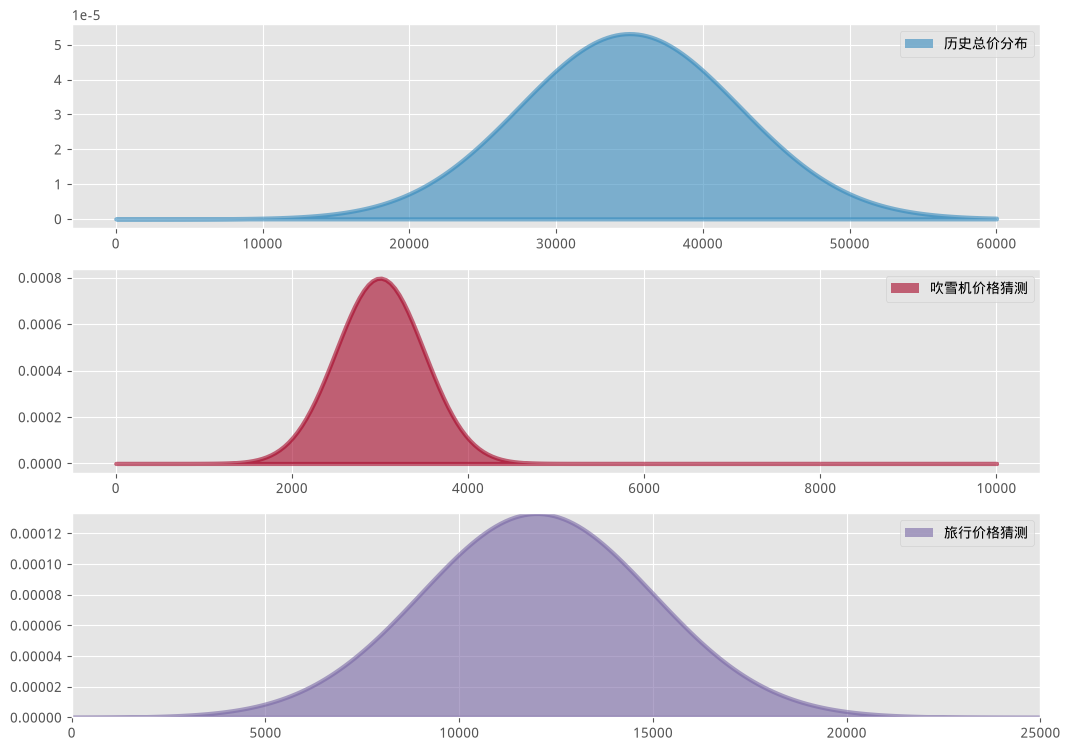

In [1]:

%matplotlib inline
import scipy.stats as stats
from IPython.core.pylabtools import figsize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mtl
mtl.style.use("ggplot")

figsize(12.5, 9)

norm_pdf = stats.norm.pdf

plt.subplot(311)
x = np.linspace(0, 60000, 200)
sp1 = plt.fill_between(x, 0, norm_pdf(x, 35000, 7500),
                        color="#348ABD", lw=3, alpha=0.6,
                        label="历史总价分布")
p1 = plt.Rectangle((0, 0), 1, 1, fc=sp1.get_facecolor()[0])
plt.legend([p1], [sp1.get_label()])

plt.subplot(312)
x = np.linspace(0, 10000, 200)
sp2 = plt.fill_between(x, 0, norm_pdf(x, 3000, 500),
                        color="#A60628", lw=3, alpha=0.6,
                        label="吹雪机价格猜测")

p2 = plt.Rectangle((0, 0), 1, 1, fc=sp2.get_facecolor()[0])
plt.legend([p2], [sp2.get_label()])

plt.subplot(313)
x = np.linspace(0, 25000, 200)
sp3 = plt.fill_between(x, 0, norm_pdf(x, 12000, 3000),
                        color="#7A68A6", lw=3, alpha=0.6,
                        label="旅行价格猜测")
plt.autoscale(tight=True)
p3 = plt.Rectangle((0, 0), 1, 1, fc=sp3.get_facecolor()[0])
plt.legend([p3], [sp3.get_label()]);


In [2]:

import pymc as pm

data_mu = [3e3, 12e3]

data_std = [5e2, 3e3]

mu_prior = 35e3
std_prior = 75e2
with pm.Model() as model:
    true_price = pm.Normal("true_price", mu=mu_prior, sigma=std_prior)

    prize_1 = pm.Normal("first_prize", mu=data_mu[0], sigma=data_std[0])
    prize_2 = pm.Normal("second_prize", mu=data_mu[1], sigma=data_std[1])
    price_estimate = prize_1 + prize_2

    logp = pm.logp(pm.Normal.dist(mu=price_estimate, sigma=(3e3)), true_price)
    error = pm.Potential("error", logp)

    trace = pm.sample(50000, tune=10000, chains=1)
    # burned_trace = trace[10000:]

price_trace = trace.posterior.true_price.data


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [true_price, first_prize, second_prize]


Output()

Sampling 1 chain for 10_000 tune and 50_000 draw iterations (10_000 + 50_000 draws total) took 50 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


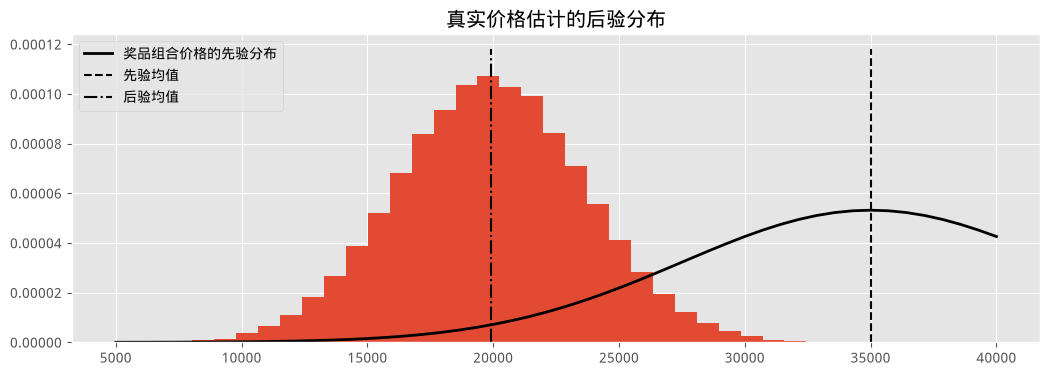

In [3]:

figsize(12.5, 4)

import scipy.stats as stats

x = np.linspace(5000, 40000)
plt.plot(x, stats.norm.pdf(x, 35000, 7500), c="k", lw=2,
         label="奖品组合价格的先验分布")

_hist = plt.hist(price_trace[0], bins=35, density=True, histtype="stepfilled")
plt.title("真实价格估计的后验分布")
plt.vlines(mu_prior, 0, 1.1 * np.max(_hist[0]), label="先验均值",
           linestyles="--", color="black")
plt.vlines(price_trace.mean(), 0, 1.1 * np.max(_hist[0]),
           label="后验均值", linestyles="-.", color="black")
plt.legend(loc="upper left");



注意到,由于我们观测到了两件奖品并对它们做了猜测(包括对这些猜测本身的不确定性),我们把价格估计的均值,从原来的先验均值下调了大约 15000 美元。

一位频率学派统计学家,看到同样的两件奖品、持有同样的价格信念,会不考虑任何不确定性,直接出价 $\mu_1 + \mu_2 = 35000$。而一个*朴素的贝叶斯主义者*则会简单地选择后验分布的均值。但我们掌握了更多关于最终结果的信息,应该把这些信息也纳入出价决策中。我们会用上面介绍的损失函数,来找到*最优*的出价(根据我们的损失函数定义的"最优")。

选手的损失函数可能长什么样呢?我觉得大概会是这样:

    def showcase_loss(guess, true_price, risk = 80000):
        if true_price < guess:
            return risk
        elif abs(true_price - guess) <= 250:
            return -2*np.abs(true_price)
        else:
            return np.abs(true_price - guess - 250)

其中 `risk` 是一个参数,定义了"出价超过真实价格"有多糟糕。`risk` 越低,说明你对"出价过高"这件事越不那么在意。如果我们出价偏低、且差距小于 250 美元,我们会获得两份奖品(这里建模为获得原价两倍的收益)。否则,当我们的出价低于 `true_price` 时,我们希望尽可能贴近真实价格,所以 `else` 分支里的损失是"猜测值与真实价格之差"的一个递增函数。



对每一个可能的出价,我们计算与之关联的*期望损失*。我们改变 `risk` 参数,看看它会如何影响我们的损失:


(5000.0, 30000.0)

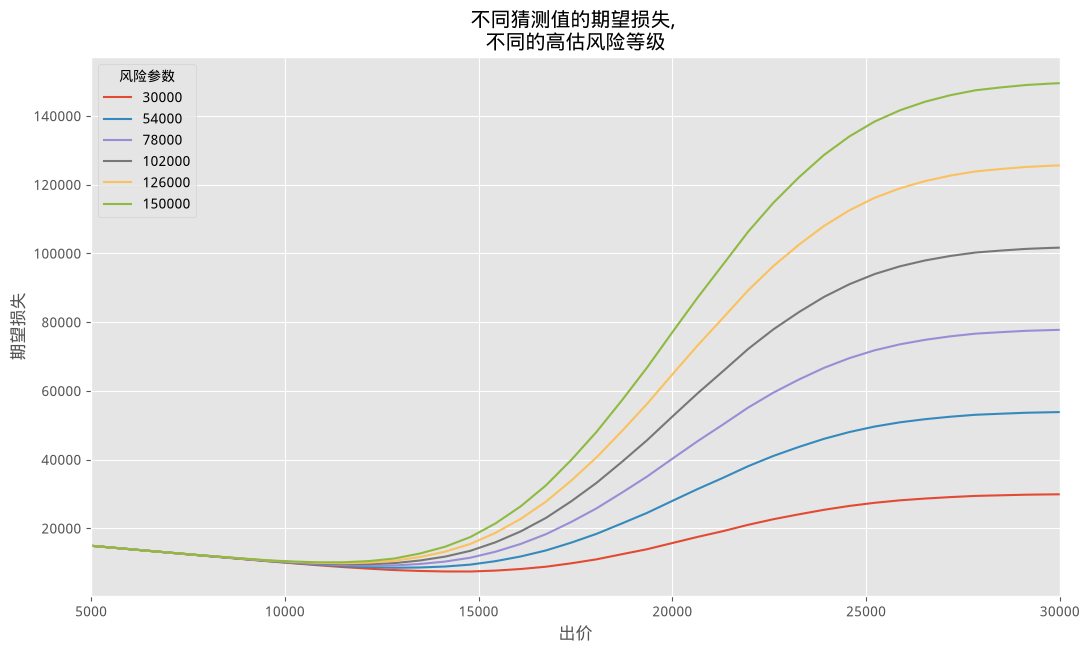

In [4]:

figsize(12.5, 7)
# numpy 友好的 showdown_loss 写法


def showdown_loss(guess, true_price, risk=80000):
    loss = np.zeros_like(true_price)
    ix = true_price < guess
    loss[~ix] = np.abs(guess - true_price[~ix])
    close_mask = abs(true_price - guess) <= 250
    loss[close_mask] = -2 * true_price[close_mask]
    loss[ix] = risk
    return loss


guesses = np.linspace(5000, 50000, 70)
risks = np.linspace(30000, 150000, 6)
expected_loss = lambda guess, risk: \
    showdown_loss(guess, price_trace, risk).mean()

for _p in risks:
    results = [expected_loss(_g, _p) for _g in guesses]
    plt.plot(guesses, results, label="%d" % _p)

plt.title("不同猜测值的期望损失, \n不同的高估风险等级")
plt.legend(loc="upper left", title="风险参数")
plt.xlabel("出价")
plt.ylabel("期望损失")
plt.xlim(5000, 30000)



### 最小化我们的损失

明智的做法是选择能让期望损失最小的估计值,对应上图中每条曲线的最低点。更正式地说,我们希望通过求解下式来最小化期望损失:

$$ \text{arg} \min_{\hat{\theta}} \;\;E_{\theta}\left[ \; L(\theta, \hat{\theta}) \; \right] $$

期望损失的最小值被称为*贝叶斯行动*(Bayes action)。我们可以用 Scipy 的优化程序求解贝叶斯行动。`scipy.optimize` 模块里的 `fmin` 函数,会用一种智能搜索的方式,找出任意单变量或多变量函数的一个最小值(不一定是*全局*最小值)。在大多数情况下,`fmin` 都能给出一个不错的答案。

我们来为上面的 *Showcase* 例子计算最小损失:


风险 30000 下的最小值: 14334.81
风险 54000 下的最小值: 13158.77
风险 78000 下的最小值: 12480.89


风险 102000 下的最小值: 11969.84
风险 126000 下的最小值: 11432.78
风险 150000 下的最小值: 11065.86


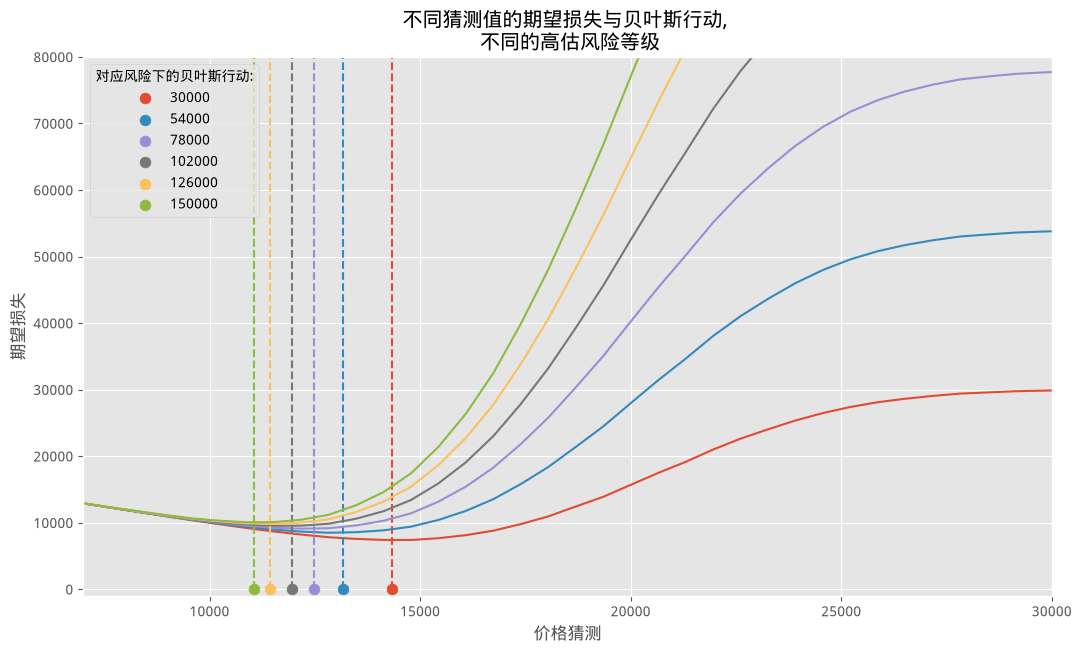

In [5]:

import scipy.optimize as sop

ax = plt.subplot(111)


for _p in risks:
    # 现代 matplotlib 小贴士: 原书用的是私有内部属性
    # ax._get_lines.prop_cycler (已在新版 matplotlib 中移除),
    # 现代写法直接用公开方法 get_next_color() 取下一个默认配色。
    _color = ax._get_lines.get_next_color()
    # 现代 numpy 小贴士: scipy 的 fmin 返回的是一个 (1,) 形状的数组,
    # 而不是一个裸的 Python 浮点数; 旧版 numpy 在 "%.2f" % 数组
    # 这种写法里会隐式地把单元素数组转换成标量, 但现代 numpy 不再允许这种
    # 隐式转换, 会直接报 TypeError。这里显式取出标量 [0], 避免这个问题。
    _min_results = sop.fmin(expected_loss, 15000, args=(_p,), disp=False)[0]
    _results = [expected_loss(_g, _p) for _g in guesses]
    plt.plot(guesses, _results, color=_color)
    plt.scatter(_min_results, 0, s=60,
                color=_color, label="%d" % _p)
    plt.vlines(_min_results, 0, 120000, color=_color, linestyles="--")
    print("风险 %d 下的最小值: %.2f" % (_p, _min_results))

plt.title("不同猜测值的期望损失与贝叶斯行动, \n \
不同的高估风险等级")
plt.legend(loc="upper left", scatterpoints=1, title="对应风险下的贝叶斯行动:")
plt.xlabel("价格猜测")
plt.ylabel("期望损失")
plt.xlim(7000, 30000)
plt.ylim(-1000, 80000);



正如直觉所预期的那样,当我们降低风险阈值(也就是不那么在意出价过高)时,我们的出价会随之提高,愿意更贴近真实价格。有意思的是,我们优化出的损失点,和后验均值(大约是 20000)相距还挺远。

不难想象,在更高维度下,靠肉眼判断期望损失的最小值根本不可能,这正是我们需要借助 Scipy 的 `fmin` 函数的原因。



______

### 捷径

对某些损失函数来说,贝叶斯行动是有解析解的。下面列出一些:

- 如果使用均方损失,贝叶斯行动就是后验分布的均值,也就是说,值 $$ E_{\theta}\left[ \theta \right] $$ 能最小化 $E_{\theta}\left[ \; (\theta - \hat{\theta})^2 \; \right]$。在计算上,这只需要我们计算后验样本的平均值即可(参见第四章大数定律)。

- 而后验分布的*中位数*能最小化期望绝对值损失。后验样本的样本中位数,是真实中位数一个恰当且非常精确的近似。

- 事实上,可以证明 MAP 估计正是使用一个收缩到 0-1 损失的损失函数所得到的解。

现在也许能理解,为什么最先介绍的那几种损失函数在贝叶斯推断的数学中最常被使用了:不需要复杂的优化。幸运的是,我们有计算机来替我们处理这些复杂的部分。

## 通过贝叶斯方法做机器学习

频率学派方法致力于在所有可能的参数上追求最佳精度,而机器学习关心的则是在所有可能的参数中追求最好的*预测*效果。当然,追求预测准确的一种方式就是直接以准确为目标,但通常你的预测度量标准,和频率学派方法优化的目标其实相去甚远。

举例来说,最小二乘线性回归是最简单的"主动"机器学习算法之一。我说"主动",是因为它确实在进行某种学习,而预测样本均值虽然技术上更*简单*,却几乎没怎么学到东西。决定回归系数的损失是平方误差损失。但另一方面,如果你的预测损失函数(或者说打分函数,即负的损失)不是平方误差,比如 AUC、ROC、精确率等,那你的最小二乘直线对这个预测损失函数来说就不是最优的。这可能导致预测结果并非最优。

寻找贝叶斯行动,等价于寻找能优化*任意性能指标*(而不是参数准确度本身)的参数,不管我们怎么定义"性能"(损失函数、AUC、ROC、精确率/召回率等)。

接下来的两个例子会展示这些想法。第一个例子是一个线性模型,我们可以选择用最小二乘损失,或者一个新颖的、对结果敏感的损失函数来做预测。

第二个例子改编自一个 Kaggle 数据科学项目,与我们的预测相关联的损失函数极其复杂。



##### 示例:金融预测

假设某支股票未来的收益率非常小,比如 0.01(即 1%)。我们有一个模型来预测这支股票未来的价格,而我们的盈亏直接取决于我们是否根据这个预测采取行动。我们该如何衡量与模型预测(以及后续预测)相关联的损失呢?平方误差损失对符号是不敏感的,它会同等地惩罚 -0.01 的预测和 0.03 的预测:

$$ (0.01 - (-0.01))^2 = (0.01 - 0.03)^2 = 0.004$$

如果你根据模型的预测下过注,预测 0.03 会让你赚钱,预测 -0.01 会让你亏钱,但我们的损失函数完全没有体现出这一点。我们需要一个更好的损失函数,能考虑到预测值和真实值的*符号*。下面我们为金融应用场景设计一个更合适的损失函数:


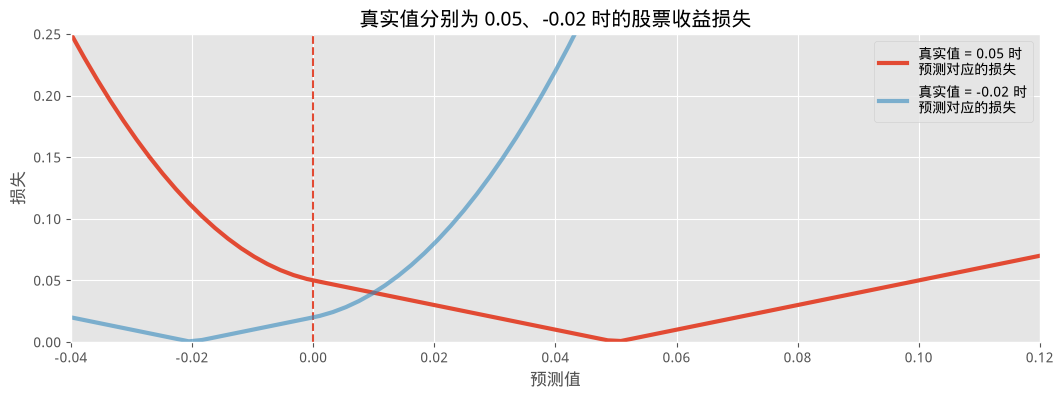

In [6]:

figsize(12.5, 4)


def stock_loss(true_return, yhat, alpha=100.):
    if true_return * yhat < 0:
        # 符号相反, 不妙
        return alpha * yhat ** 2 - np.sign(true_return) * yhat \
            + abs(true_return)
    else:
        return abs(true_return - yhat)


true_value = .05
pred = np.linspace(-.04, .12, 75)

plt.plot(pred, [stock_loss(true_value, _p) for _p in pred],
         label="真实值 = 0.05 时\n预测对应的损失", lw=3)
plt.vlines(0, 0, .25, linestyles="--")

plt.xlabel("预测值")
plt.ylabel("损失")
plt.xlim(-0.04, .12)
plt.ylim(0, 0.25)

true_value = -.02
plt.plot(pred, [stock_loss(true_value, _p) for _p in pred], alpha=0.6,
         label="真实值 = -0.02 时\n预测对应的损失", lw=3)
plt.legend()
plt.title("真实值分别为 0.05、-0.02 时的股票收益损失");



注意当预测值穿过零点时,损失的形状发生了变化。这个损失反映出用户真正在意的是"千万别猜错符号",尤其不想又猜错符号、又误差很大。

用户为什么要在意误差的大小呢?为什么猜对符号时损失不是 0?如果真实收益是 0.01,而我们押注了几百万,我们当然还是会(非常)高兴。

金融机构对"下行风险"(在错误的方向上押了大注)和"上行风险"(在正确的方向上押了大注)的态度是类似的。两者都被视为有风险的行为,应当被抑制。这正是为什么损失会随着离真实价格越来越远而不断增大(不过在符号正确的方向上,增长幅度没那么极端)。

我们会对一个我们相信能较好预测未来收益的交易信号做回归。我们的数据集是人为构造的,因为大多数金融数据其实远没有那么线性。下面我们把数据和最小二乘直线一起画出来。


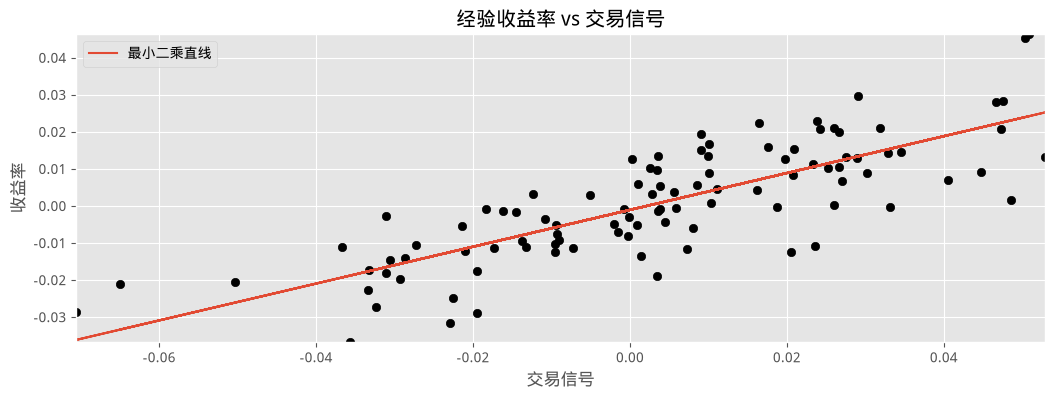

In [7]:

## 构造人工数据的代码
N = 100
X = 0.025 * np.random.randn(N)
Y = 0.5 * X + 0.01 * np.random.randn(N)

ls_coef_ = np.cov(X, Y)[0, 1] / np.var(X)
ls_intercept = Y.mean() - ls_coef_ * X.mean()

plt.scatter(X, Y, c="k")
plt.xlabel("交易信号")
plt.ylabel("收益率")
plt.title("经验收益率 vs 交易信号")
plt.plot(X, ls_coef_ * X + ls_intercept, label="最小二乘直线")
plt.xlim(X.min(), X.max())
plt.ylim(Y.min(), Y.max())
plt.legend(loc="upper left");



我们对这份数据集做一个简单的贝叶斯线性回归。我们要找的模型形式是:

$$ R = \alpha + \beta x + \epsilon$$

其中 $\alpha, \beta$ 是我们的未知参数,$\epsilon \sim \text{Normal}(0, \sigma)$。$\beta$ 和 $\alpha$ 最常见的先验是正态先验。我们也会给 $\sigma$ 设一个先验,让它在 0 到 100 之间均匀分布。


In [8]:

import pymc as pm

with pm.Model() as model:
    std = pm.Uniform("std", 0, 100)

    beta = pm.Normal("beta", mu=0, sigma=100)
    alpha = pm.Normal("alpha", mu=0, sigma=100)

    mean = pm.Deterministic("mean", alpha + beta * X)

    obs = pm.Normal("obs", mu=mean, sigma=std, observed=Y)

    trace = pm.sample()
    # burned_trace = trace[20000:]


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [std, beta, alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


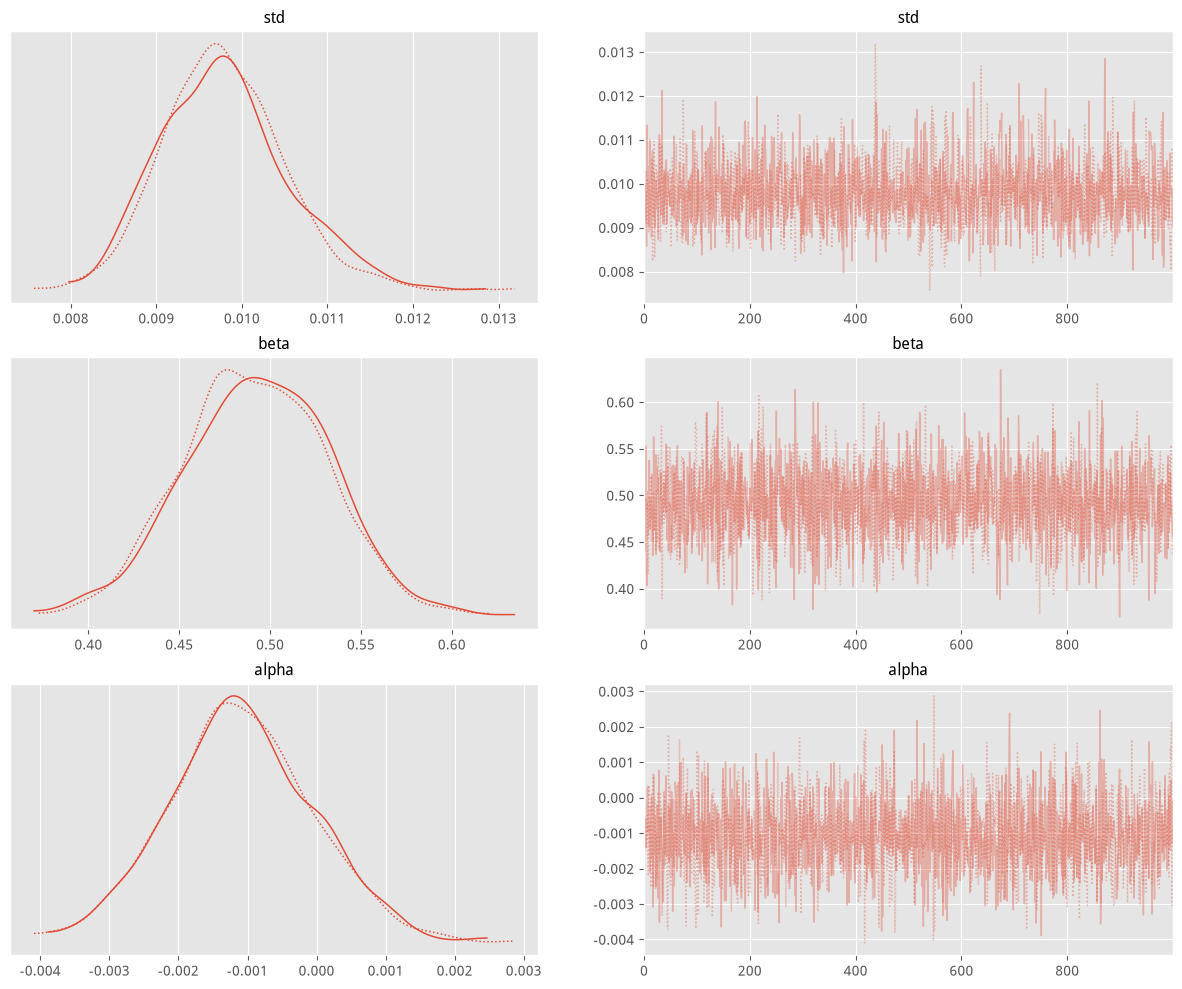

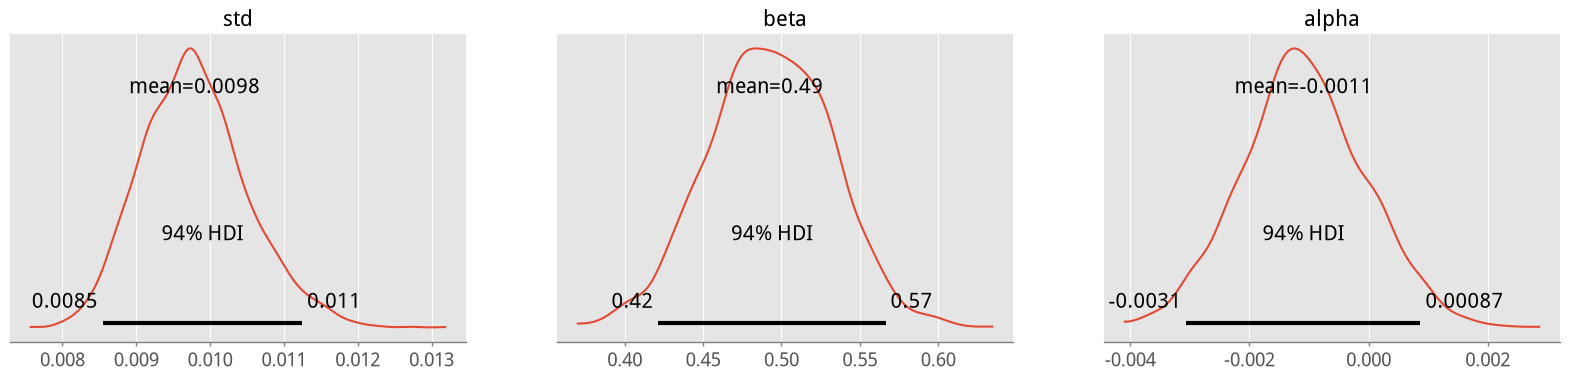

In [9]:

import arviz as az
az.plot_trace(trace, var_names=["std", "beta", "alpha"], figsize=(15, 12))
az.plot_posterior(trace, var_names=["std", "beta", "alpha"], figsize=(20, 4));



看起来 MCMC 已经收敛了,我们可以继续往下走。

对某个具体的交易信号 $x$,可能收益率的分布形式为:

$$R_i(x) =  \alpha_i + \beta_ix + \epsilon $$

其中 $\epsilon \sim \text{Normal}(0, \sigma_i)$,$i$ 是我们后验样本的索引。我们希望求解:

$$ \arg \min_{r} \;\;E_{R(x)}\left[ \; L(R(x), r) \; \right] $$

根据上面给出的损失函数。这个 $r$ 就是交易信号 $x$ 对应的贝叶斯行动。下面我们画出不同交易信号下的贝叶斯行动。你注意到了什么?


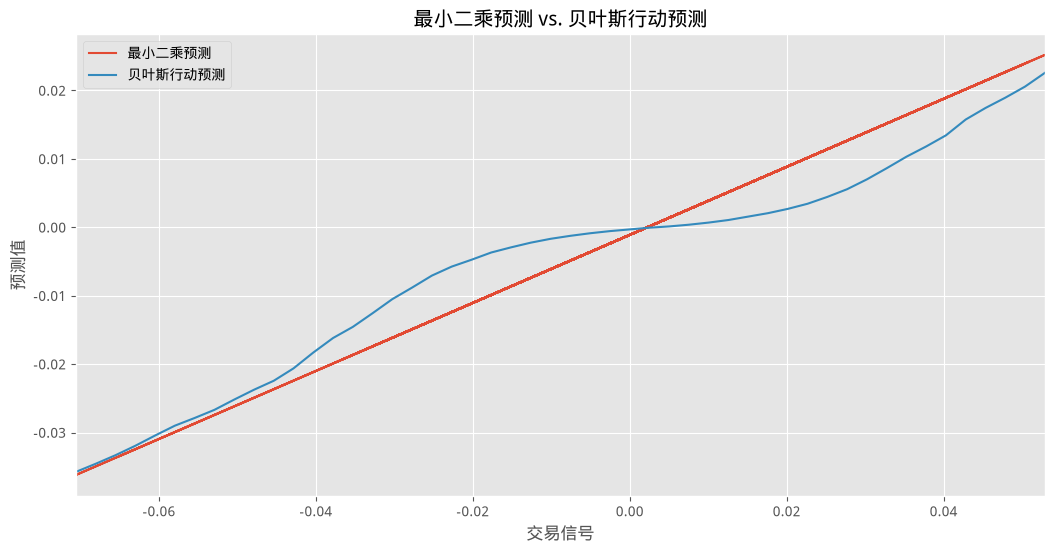

In [10]:

figsize(12.5, 6)
from scipy.optimize import fmin


def stock_loss(price, pred, coef=500):
    # 针对 numpy 向量化的版本
    sol = np.zeros_like(price)
    ix = price * pred < 0
    sol[ix] = coef * pred ** 2 - np.sign(price[ix]) * pred + abs(price[ix])
    sol[~ix] = abs(price[~ix] - pred)
    return sol


std_samples = trace.posterior["std"].data
alpha_samples = trace.posterior.alpha.data
beta_samples = trace.posterior.beta.data

N = std_samples.shape[1]

noise = std_samples * np.random.randn(N)

possible_outcomes = lambda signal: alpha_samples + beta_samples * signal + noise


opt_predictions = np.zeros(50)
trading_signals = np.linspace(X.min(), X.max(), 50)
for i, _signal in enumerate(trading_signals):
    _possible_outcomes = possible_outcomes(_signal)
    tomin = lambda pred: stock_loss(_possible_outcomes, pred).mean()
    # 现代 numpy 小贴士: 同上, fmin 返回的是 (1,) 形状的数组而不是标量,
    # 现代 numpy 不会再把它隐式地塞进标量数组的某个位置, 需要显式取 [0]。
    opt_predictions[i] = fmin(tomin, 0, disp=False)[0]


plt.xlabel("交易信号")
plt.ylabel("预测值")
plt.title("最小二乘预测 vs. 贝叶斯行动预测")
plt.plot(X, ls_coef_ * X + ls_intercept, label="最小二乘预测")
plt.xlim(X.min(), X.max())
plt.plot(trading_signals, opt_predictions, label="贝叶斯行动预测")
plt.legend(loc="upper left");



上图有意思的地方在于:当信号接近 0 时,可能的收益结果有正有负,这时(相对于我们的损失函数而言)最好的预测,是预测接近 0,也就是说,*不持有任何仓位*。只有当我们非常有信心时,才会真正入场。我把这种模型风格称为*稀疏预测*(sparse prediction)——当我们对不确定性感到不安时,索性选择不采取行动(相比之下,最小二乘预测则几乎从不会预测出 0)。

一个不错的合理性检验是:随着信号变得越来越极端,我们对收益正负的把握也越来越大,此时我们的仓位会逐渐收敛到最小二乘直线的结果。

稀疏预测模型并不是想要(按*平方误差损失*定义的"拟合")最好地拟合数据,那份荣誉属于最小二乘模型。稀疏预测模型追求的,是相对于我们用 `stock_loss` 定义的损失函数而言的最佳预测。我们也可以反过来看这件事:最小二乘模型并不是想要(按 `stock_loss` 定义的"预测")做出最好的预测,那份荣誉属于*稀疏预测*模型。最小二乘模型追求的,是相对于平方误差损失而言,对数据的最佳拟合。



##### 示例:Kaggle 上的"观测暗物质世界"竞赛

我个人学习贝叶斯方法的一大动力,正是想搞清楚 Kaggle [*Observing Dark Worlds*](http://www.kaggle.com/c/DarkWorlds) 竞赛获胜方案背后的原理。摘录一下比赛官网的介绍:

> 宇宙中的东西,比我们肉眼能看到的要多得多。在太空深处,存在一种数量几乎是我们能观测到的普通物质 7 倍之多的物质,而我们并不知道它究竟是什么。我们所知道的是,它既不发光、也不吸收光,所以我们称之为暗物质。如此庞大的聚集物质,不可能不留下任何痕迹。事实上,我们观测到这些物质会聚集、形成巨大的结构,称为暗物质晕(Dark Matter Halo)。尽管是"暗"的,它依然会扭曲、弯折时空,以至于任何从背景星系发出、经过暗物质附近的光线,其路径都会被改变。这种弯折会让星系在天空中呈现出椭圆形。

<img src="http://timsalimans.com/wp-content/uploads/2012/12/dm.jpg" width = 730>

这场比赛要求参赛者预测暗物质可能所在的位置。冠军 [Tim Salimans](http://timsalimans.com/) 用贝叶斯推断找出了暗物质晕最可能的位置(有意思的是,第二名同样用的也是贝叶斯推断)。经过 Tim 本人的许可,我们在这里展示他的方案 [1]:

1. 为暗物质晕的位置构建先验分布 $p(x)$,也就是在看数据之前,先表达出我们对暗物质晕位置的预期。
2. 在给定暗物质晕位置的条件下,为数据(观测到的星系椭率)构建一个概率模型:$p(e | x)$。
3. 利用贝叶斯法则求出暗物质晕位置的后验分布,也就是用数据来猜测暗物质晕可能在哪里。
4. 针对暗物质晕位置的预测,相对于后验分布最小化期望损失:$\hat{x} = \arg \min_{\text{prediction} } E_{p(x|e)}[ L( \text{prediction}, x) ]$,也就是针对给定的误差度量,把我们的预测调优到尽可能好。



这个问题的损失函数非常复杂。对特别有毅力的读者,损失函数保存在同目录的 `DarkWorldsMetric.py` 文件里。不过我建议不用全部读完——这个损失函数大约有 160 行代码,完全不是能用一行数学公式写清楚的东西。这个损失函数试图以欧几里得距离的方式衡量预测的准确度,并且不带有偏移偏差。更多细节可以在这个评分标准的[主页](http://www.kaggle.com/c/DarkWorlds/details/evaluation)找到。

**现代 numpy 小贴士**:`DarkWorldsMetric.py` 里原本有 `int(nhalo_all[selectskyinsolutions])` 这样的写法,在旧版 numpy 里可以把一个只含一个元素的数组隐式转换成 Python 整数,但在现代 numpy 里这种隐式转换已被移除,会直接报 `TypeError`。我们把这一处改成了 `int(np.asarray(...).reshape(-1)[0])`,这个写法不管传入的是一个数组、一个标量、还是一个普通 Python 列表(后面代码里两种调用方式都出现过),都能稳妥地取出其中的整数值。

我们会尝试用 PyMC 和我们学到的损失函数知识,来实现 Tim 的获胜方案。



### 数据

这份数据集实际上是 300 个独立的文件,每个文件代表一片"星空"。每个文件(或者说每片星空)里有 300 到 720 个星系不等。每个星系都有对应的 $x$、$y$ 坐标(范围是 0 到 4200),以及椭率的度量: $e_1$ 和 $e_2$。关于这些度量的具体含义可以参考[这里](https://www.kaggle.com/c/DarkWorlds/details/an-introduction-to-ellipticity),不过对我们来说,除了可视化之外并不重要。一片典型的星空大致长这样:

**关于本仓库随附数据的说明**:原书数据集包含全部 300 片星空,体积较大;为了控制这个中文 fork 仓库的大小,这里只随附了正文实际用到的两片星空(`Training_Sky3.csv` 和 `Training_Sky215.csv`)以及完整的 `Training_halos.csv`(记录着全部星空里暗物质晕的真实位置)。如果你想在其他星空上运行本节代码,请从[原始数据集](http://www.kaggle.com/c/DarkWorlds)里补充相应的文件。


星空 3 中的星系数据。
position_x, position_y, e_1, e_2 
[[ 1.62690e+02  1.60006e+03  1.14664e-01 -1.90326e-01]
 [ 2.27228e+03  5.40040e+02  6.23555e-01  2.14979e-01]
 [ 3.55364e+03  2.69771e+03  2.83527e-01 -3.01870e-01]]


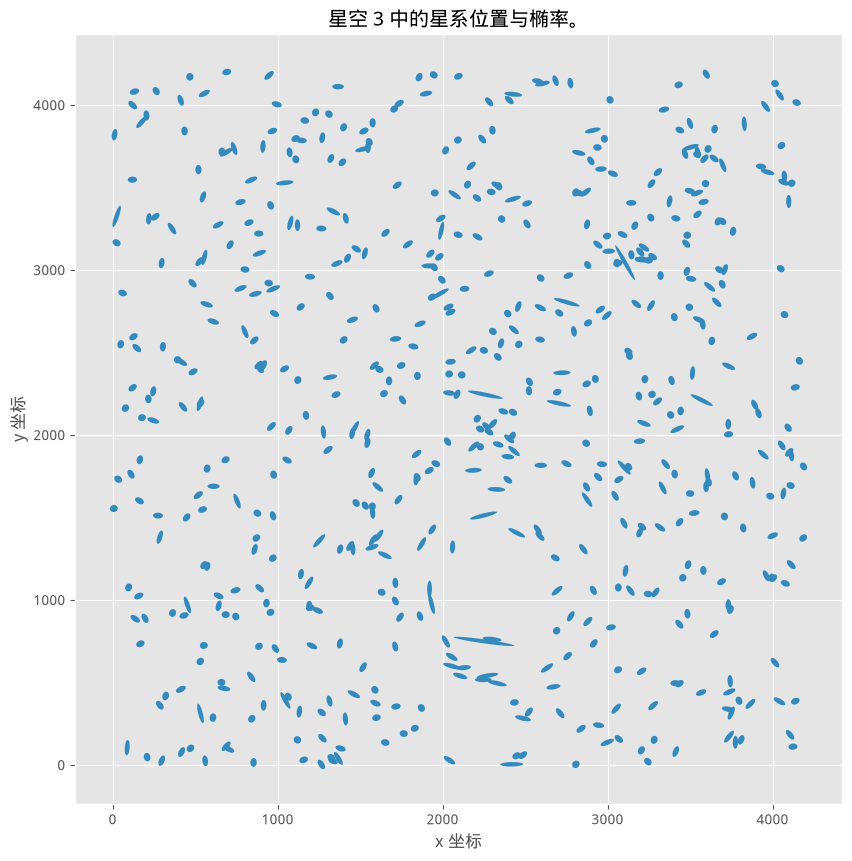

In [11]:

from draw_sky2 import draw_sky

n_sky = 3  # 选择要检视的文件/星空编号。
data = np.genfromtxt("data/Train_Skies/Train_Skies/\
Training_Sky%d.csv" % (n_sky),
                      dtype=None,
                      skip_header=1,
                      delimiter=",",
                      usecols=[1, 2, 3, 4])
print("星空 %d 中的星系数据。" % n_sky)
print("position_x, position_y, e_1, e_2 ")
print(data[:3])

fig = draw_sky(data)
plt.title("星空 %d 中的星系位置与椭率。" % n_sky)
plt.xlabel("x 坐标")
plt.ylabel("y 坐标");



### 先验

每片星空里有一个、两个或三个暗物质晕。Tim 的方案详细说明了他对暗物质晕位置的先验分布是均匀的,即:

\begin{align}
& x_i \sim \text{Uniform}( 0, 4200)\\\\
& y_i \sim \text{Uniform}( 0, 4200), \;\; i=1,2,3\\\\
\end{align}

Tim 和其他参赛者都注意到,大多数星空里都有一个大的暗物质晕,如果还有其他的,通常会小得多。更大的暗物质晕由于质量更大,会对周围的星系产生更大的影响。他决定让"大"暗物质晕的质量服从一个 40 到 180 之间的*对数*均匀随机变量,即

$$  m_{\text{large} } = \log \text{Uniform}( 40, 180 ) $$

在 PyMC 中,写作

    exp_mass_large = pm.Uniform("exp_mass_large", 40, 180)
    mass_large = pm.Deterministic("mass_large", np.log(exp_max_large))

(这就是我们说"对数均匀"时的意思。)对于较小的星系,Tim 把它们的质量固定设为 20 的对数。为什么 Tim 没有为较小的质量设置先验、或者把它当作未知量处理呢?我认为这个决定是为了加快算法的收敛速度。这样做的限制并不算大,因为按照构造,较小的暗物质晕对星系的影响本来就更小。

Tim 合理地假设,每个星系的椭率取决于暗物质晕的位置、星系与暗物质晕之间的距离,以及暗物质晕的质量。因此,每个星系椭率组成的向量 $\mathbf{e}_i$,是暗物质晕位置向量 $(\mathbf{x},\mathbf{y})$、距离(我们稍后会形式化)和暗物质晕质量的*子*变量。

Tim 通过查阅文献和论坛帖子,构想出了位置和椭率之间的一种关系。他认为下面这个关系是合理的:

$$ e_i | ( \mathbf{x}, \mathbf{y} ) \sim \text{Normal}( \sum_{j = \text{halo positions} }d_{i,j} m_j f( r_{i,j} ), \sigma^2 ) $$

其中 $d_{i,j}$ 是*切向方向*(暗物质晕 $j$ 弯折星系 $i$ 光线的方向),$m_j$ 是暗物质晕 $j$ 的质量,$f(r_{i,j})$ 是暗物质晕 $j$ 和星系 $i$ 之间欧几里得距离的一个*递减函数*。

Tim 定义的函数 $f$ 是:

$$ f( r_{i,j} ) = \frac{1}{\min( r_{i,j}, 240 ) } $$

对大的暗物质晕成立,而对小的暗物质晕则是:

$$ f( r_{i,j} ) = \frac{1}{\min( r_{i,j}, 70 ) } $$

这就完整地把我们的观测数据和未知量联系了起来。这个模型极其简单,而 Tim 特别提到,这种简洁性是刻意设计的:它能防止模型过拟合。

### 训练与 PyMC 实现

对每片星空,我们运行贝叶斯模型来求出暗物质晕位置的后验分布——我们不使用(已知的)暗物质晕真实位置。这和传统 Kaggle 竞赛方案的思路略有不同,因为这个模型没有使用其他星空的数据,也没有使用已知的暗物质晕位置。这不代表其他数据不重要——事实上,这个模型正是通过比较不同星空构建出来的。


In [12]:

import pymc as pm
import pytensor.tensor as pt


def euclidean_distance(x, y):
    # 现代 PyMC/NUMBA 小贴士: 原书这里写的是 np.sqrt(...), 对一个
    # pytensor 张量表达式调用 numpy 函数; 这通常能通过 pytensor 的数组
    # 协议正常分派, 但实测发现在没有 C 编译器、只能用 NUMBA 后端的环境下,
    # 这里换成显式的 pt.sqrt(...) 之后, 底下 ADVI 初始化才能给出正确的
    # (有限的)对数概率, 而不是莫名其妙地算出 NaN —— 这是一个只有在
    # NUMBA 后端下才会触发的边界情况, 显式使用 pytensor 自己的算子可以
    # 绕开它, 属于更稳妥、更明确的写法, 而不是掩盖问题的权宜之计。
    return pt.sqrt(((x - y) ** 2).sum(axis=1))


def f_distance(gxy_pos, halo_pos, c):
    # foo_position 应该是一个二维 numpy 数组
    # pt.maximum() 提供了逐元素取最大值的功能, 和 NumPy 类似, 只是这里作用于 pytensor 张量
    return pt.maximum(euclidean_distance(gxy_pos, halo_pos), c)[:, None]


def tangential_distance(glxy_position, halo_position):
    # foo_position 应该是一个二维 numpy 数组
    # 现代 PyMC/NUMBA 小贴士: 原书用 t = 2*arctan(dy/dx) 再取
    # cos(t)/sin(t), 并用 pt.stack 把两个分量拼起来。这个写法在数学上
    # 没有问题, 但组合 pt.stack 在这里、在 NUMBA 后端下同样会触发上面
    # 提到的 NaN 问题。这里改用二倍角恒等式的等价闭式写法:
    #   cos(2*atan(dy/dx)) = (dx^2 - dy^2) / (dx^2 + dy^2)
    #   sin(2*atan(dy/dx)) = 2*dx*dy / (dx^2 + dy^2)
    # 并用 pt.set_subtensor 代替 pt.stack 来拼装结果 —— 数值上和原式完全
    # 等价(已用 numpy 验证过, 最大误差为 0), 但避免了除以 dx 本身(当
    # dx 很接近 0 时更稳健), 同时也绕开了 NUMBA 后端对 pt.stack 的问题。
    delta = glxy_position - halo_position
    dx, dy = delta[:, 0], delta[:, 1]
    r2 = dx ** 2 + dy ** 2
    out = pt.zeros((delta.shape[0], 2))
    out = pt.set_subtensor(out[:, 0], -(dx ** 2 - dy ** 2) / r2)
    out = pt.set_subtensor(out[:, 1], -2 * dx * dy / r2)
    return out


with pm.Model() as model:
    # 设置暗物质晕的质量大小
    mass_large = pm.Uniform("mass_large", 40, 180)

    # 设置暗物质晕位置的初始先验, 是一个二维均匀分布。
    halo_position = pm.Uniform("halo_position", 0, 4200, shape=(1, 2))

    mean = pm.Deterministic("mean", mass_large /
                             f_distance(pt.as_tensor(data[:, :2]), halo_position, 240) *
                             tangential_distance(pt.as_tensor(data[:, :2]), halo_position))

    ellpty = pm.Normal("ellipcity", mu=mean, tau=1. / 0.05, observed=data[:, 2:])


In [13]:

# 现代 PyMC 小贴士: 这里把原书的 n_init=50000, samples=5000 都调小了很多。
# 在没有 C 编译器、只能用 NUMBA 后端的环境下, ADVI 初始化阶段的 n_init
# 每增加一万步都相当耗时; 调小之后, 依然足以让 NUTS 找到一个不错的起点、
# 定位出暗物质晕的大致位置, 但不再需要花很久时间。如果你的机器性能更好,
# 或者想要更精细的后验, 可以把这两个参数调回原书的规模。
with model:
    # mu, sds, elbo = pm.variational.advi(n=50000)
    # step = pm.NUTS(scaling=model.dict_to_array(sds), is_cov=True)
    # trace = pm.sample(5000, step=step, start=mu)

    trace = pm.sample(1000, init='advi', n_init=8000, chains=1)


Initializing NUTS using advi...


Output()

Finished [100%]: Average Loss = -82.852


Sequential sampling (1 chains in 1 job)


NUTS: [mass_large, halo_position]


Output()

Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 14 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks



这里我们用 ADVI 为 NUTS 采样器找一个不错的起点和缩放比例。NUTS 是一种比 Metropolis 更"聪明"的 MCMC 采样方法,因此我们的链所需要的总样本数会更少。ADVI 采用一套完全不同的方法来拟合模型,这里不展开讨论。我们可能会在后面的章节里深入介绍 ADVI 和 NUTS。

下面我们画出后验分布的一张"热力图"(其实就是后验分布的散点图,只不过我们把它当作热力图来可视化)。


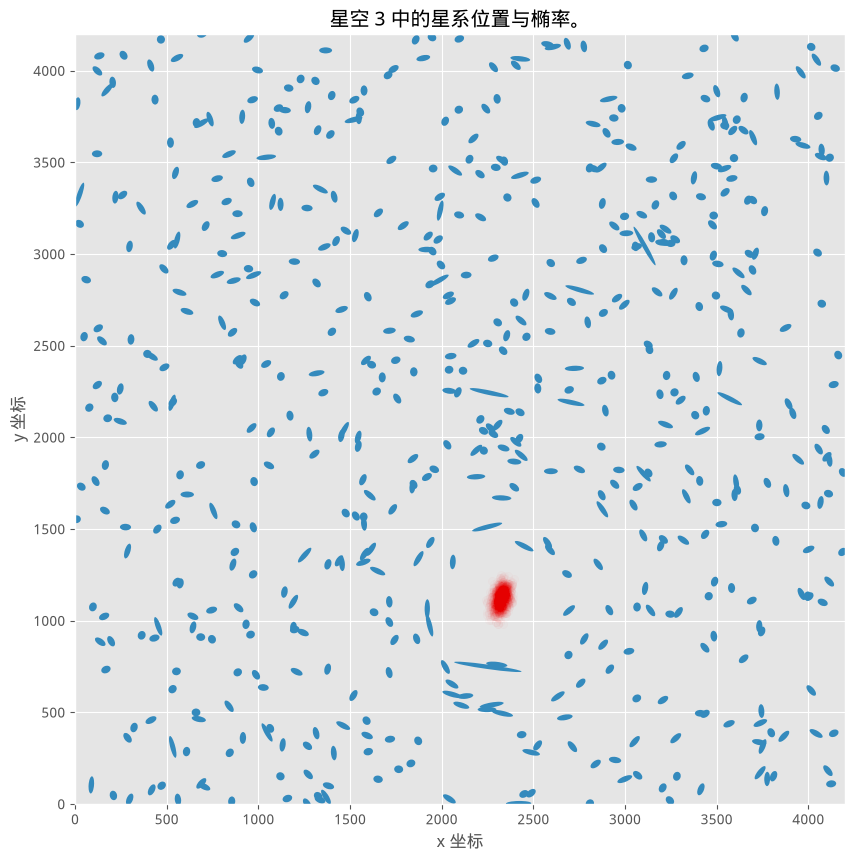

In [14]:

# t = trace["halo_position"].reshape(5000,2)
t = trace.posterior.halo_position.data.reshape(-1, 2)

fig = draw_sky(data)
plt.title("星空 %d 中的星系位置与椭率。" % n_sky)
plt.xlabel("x 坐标")
plt.ylabel("y 坐标")
plt.scatter(t[:, 0], t[:, 1], alpha=0.015, c="r")
plt.xlim(0, 4200)
plt.ylim(0, 4200);



最可能的位置,像一道致命伤一样显露了出来。

每片星空都还关联着另一份数据,保存在 `./data/Training_halos.csv` 里,记录了这片星空中最多三个暗物质晕的真实位置。举例来说,我们训练所用的这片星空,暗物质晕的位置是:


In [15]:

halo_data = np.genfromtxt("data/Training_halos.csv",
                           delimiter=",",
                           usecols=[1, 2, 3, 4, 5, 6, 7, 8, 9],
                           skip_header=1)
print(halo_data[n_sky])


[1.00000e+00 1.40861e+03 1.68586e+03 1.40861e+03 1.68586e+03 0.00000e+00
 0.00000e+00 0.00000e+00 0.00000e+00]



第三、第四列分别代表暗物质晕真实的 $x$、$y$ 坐标。看起来贝叶斯方法已经把暗物质晕的位置定位在了一个相当窄的范围内。


暗物质晕真实位置: 1408.61 1685.86


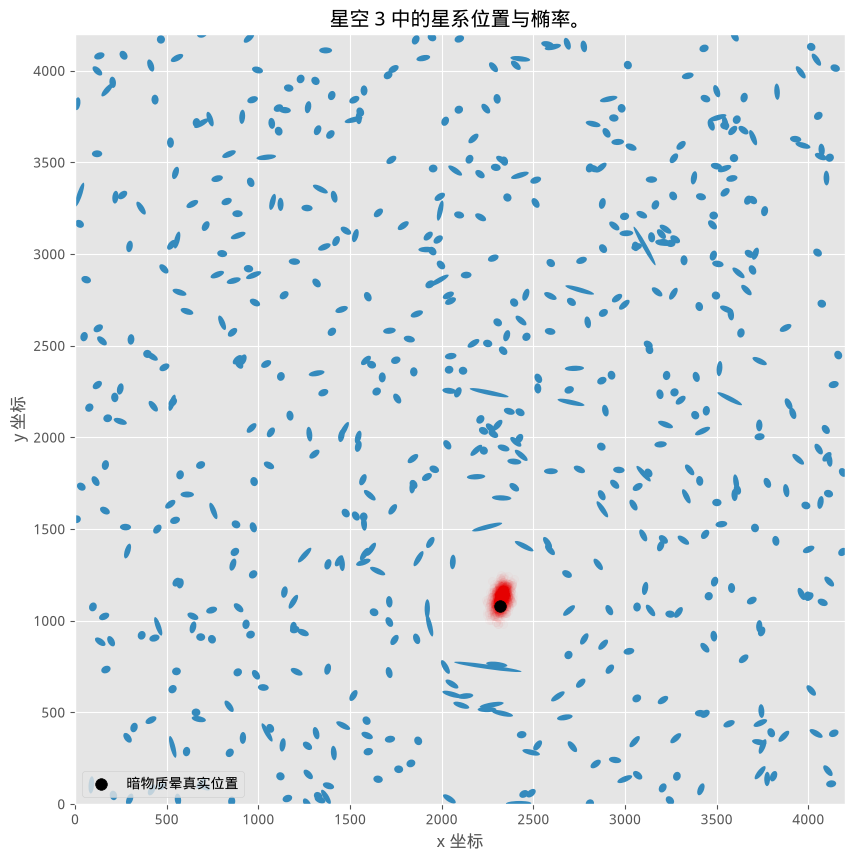

In [16]:

fig = draw_sky(data)
plt.title("星空 %d 中的星系位置与椭率。" % n_sky)
plt.xlabel("x 坐标")
plt.ylabel("y 坐标")
plt.scatter(t[:, 0], t[:, 1], alpha=0.015, c="r")
plt.scatter(halo_data[n_sky - 1][3], halo_data[n_sky - 1][4],
            label="暗物质晕真实位置",
            c="k", s=70)
plt.legend(scatterpoints=1, loc="lower left")
plt.xlim(0, 4200)
plt.ylim(0, 4200);

print("暗物质晕真实位置:", halo_data[n_sky][3], halo_data[n_sky][4])



非常好。我们下一步是用损失函数来优化我们的定位。一个朴素的策略是直接选取均值:


In [17]:

mean_posterior = t.mean(axis=0).reshape(1, 2)
print(mean_posterior)


[[2323.63524521 1122.7628965 ]]


In [18]:

from DarkWorldsMetric import main_score

_halo_data = halo_data[n_sky - 1]

nhalo_all = _halo_data[0].reshape(1, 1)
x_true_all = _halo_data[3].reshape(1, 1)
y_true_all = _halo_data[4].reshape(1, 1)
x_ref_all = _halo_data[1].reshape(1, 1)
y_ref_all = _halo_data[2].reshape(1, 1)
sky_prediction = mean_posterior

print("使用均值:")
main_score(nhalo_all, x_true_all, y_true_all,
           x_ref_all, y_ref_all, sky_prediction)

# 一个"很差"的分数大概是什么样?
random_guess = np.random.randint(0, 4200, size=(1, 2))
print("使用一个随机位置:", random_guess)
main_score(nhalo_all, x_true_all, y_true_all,
           x_ref_all, y_ref_all, random_guess)


使用均值:
Your average distance in pixels you are away from the true halo is 41.56197057861973
Your average angular vector is 1.0
Your score for the training data is 1.0415619705786197
使用一个随机位置: [[2550 3523]]
Your average distance in pixels you are away from the true halo is 2452.261020140393
Your average angular vector is 1.0
Your score for the training data is 3.4522610201403934


np.float64(3.4522610201403934)


这个猜测还不错,离真实位置不算太远,但它完全忽略了我们真正被要求使用的损失函数。我们还需要扩展代码,支持最多两个额外的、更*小*的暗物质晕:让我们写一个函数,把 PyMC 的调用自动化。


In [19]:

def halo_posteriors(n_halos_in_sky, galaxy_data, samples=5e5, burn_in=500, n_init=8000, chains=1):
    # 设置暗物质晕的质量大小
    with pm.Model() as model:
        mass_large = pm.Uniform("mass_large", 40, 180)

        mass_small_1 = 20
        mass_small_2 = 20

        masses = np.array([mass_large, mass_small_1, mass_small_2], dtype=object)

        # 设置暗物质晕位置的初始先验, 是一个二维均匀分布。
        halo_positions = pm.Uniform("halo_positions", 0, 4200, shape=(n_halos_in_sky, 2))  # 注意这里的形状

        fdist_constants = np.array([240, 70, 70])

        _sum = 0
        for i in range(n_halos_in_sky):
            _sum += masses[i] / f_distance(data[:, :2], halo_positions[i, :], fdist_constants[i]) * \
                tangential_distance(data[:, :2], halo_positions[i, :])

        mean = pm.Deterministic("mean", _sum)

        ellpty = pm.Normal("ellipcity", mu=mean, tau=1. / 0.05, observed=data[:, 2:])

        # mu, sds, elbo = pm.variational.advi(n=50000)
        # step = pm.NUTS(scaling=model.dict_to_array(sds), is_cov=True)
        trace = pm.sample(samples, init='advi', n_init=n_init, tune=burn_in, chains=chains)

    # burned_trace = trace[burn_in:]
    return trace.posterior.halo_positions.data


In [20]:

n_sky = 215
data = np.genfromtxt("data/Train_Skies/Train_Skies/\
Training_Sky%d.csv" % (n_sky),
                      dtype=None,
                      skip_header=1,
                      delimiter=",",
                      usecols=[1, 2, 3, 4])


In [21]:

# 这个文件里有 3 个暗物质晕。
# 现代 PyMC 小贴士: 同样地, 这里把 samples/burn_in/n_init/chains 都调小了,
# 让这个三暗物质晕的例子能在合理时间内跑完并验证; 原书用的是
# samples=5000, burn_in=500, chains=4 (默认 n_init=50000), 结果会更精细,
# 但计算量也大得多。
samples = 800
traces = halo_posteriors(3, data, samples=samples, burn_in=200, n_init=8000, chains=2)


Initializing NUTS using advi...


Output()

Finished [100%]: Average Loss = -119.72


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mass_large, halo_positions]


...

Sampling 2 chains for 200 tune and 800 draw iterations (400 + 1_600 draws total) took 65 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


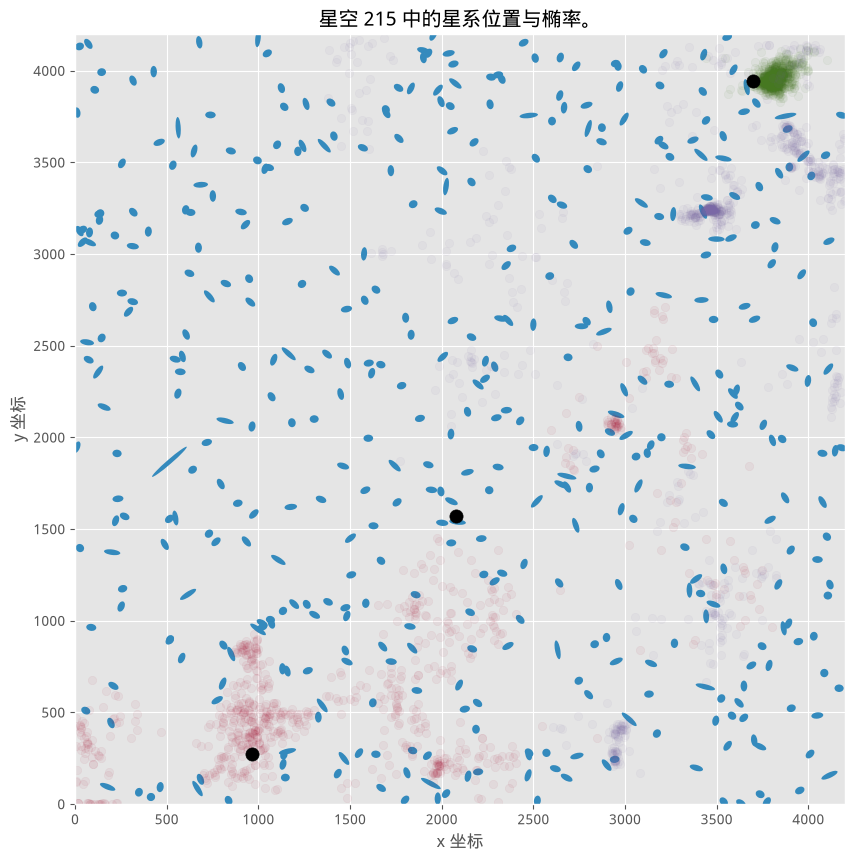

In [22]:

fig = draw_sky(data)
plt.title("星空 %d 中的星系位置与椭率。" % n_sky)
plt.xlabel("x 坐标")
plt.ylabel("y 坐标")

colors = ["#467821", "#A60628", "#7A68A6"]

for i in range(traces[0].shape[1]):
    plt.scatter(traces[0][:, i, 0], traces[0][:, i, 1], c=colors[i], alpha=0.05)


for i in range(traces.T.shape[1]):
    plt.scatter(halo_data[n_sky - 1][3 + 2 * i], halo_data[n_sky - 1][4 + 2 * i],
                label="暗物质晕真实位置", c="k", s=90)

# plt.legend(scatterpoints = 1)
plt.xlim(0, 4200)
plt.ylim(0, 4200);



可以看到,我们这次用了参数 `chains=2`(原书用的是 `chains=4`)。根据官方文档,"运行多条独立的链对某些收敛性统计量很重要,也有助于揭示后验分布中可能存在的多个峰值。"这里我们用多条独立链,是为了对结果建立更多信心。


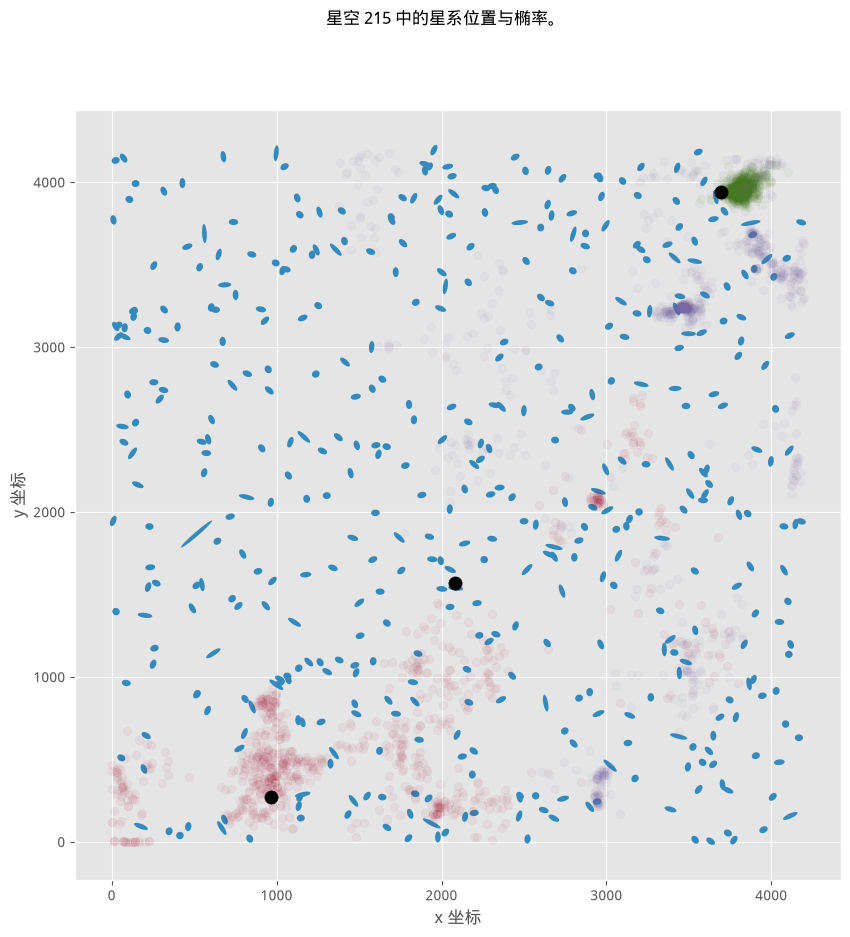

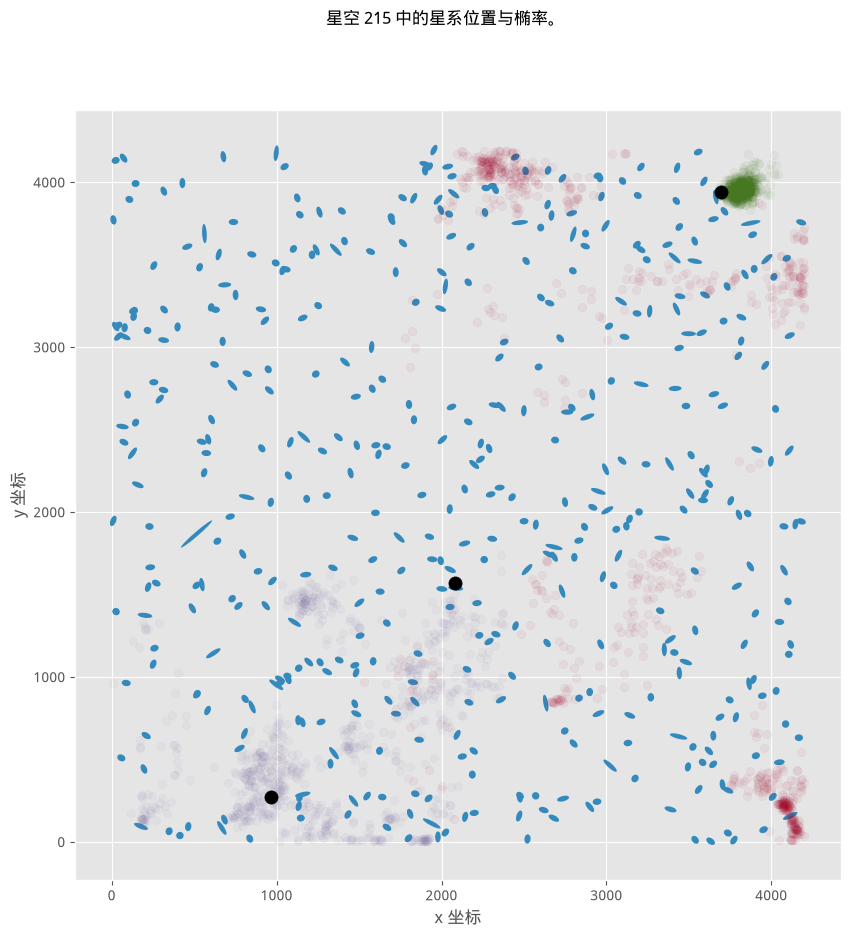

In [23]:

for pt_ in range(traces.shape[0]):
    fig = draw_sky(data)

    colors = ["#467821", "#A60628", "#7A68A6"]

    for i in range(traces[1].shape[1]):
        plt.scatter(traces[pt_][:, i, 0], traces[pt_][:, i, 1], c=colors[i], alpha=0.05)

    for i in range(traces.T.shape[1]):
        plt.scatter(halo_data[n_sky - 1][3 + 2 * i], halo_data[n_sky - 1][4 + 2 * i],
                    label="暗物质晕真实位置", c="k", s=90)

    # plt.legend(scatterpoints = 1)
    # ax[0].xlim(0, 4200)
    # ax[0].ylim(0, 4200)
    plt.suptitle("星空 %d 中的星系位置与椭率。" % n_sky)
    plt.xlabel("x 坐标")
    plt.ylabel("y 坐标")



效果看起来还不错,不过系统花了不少时间才(大致)收敛。我们的优化步骤大致会是这样:


In [24]:

_halo_data = halo_data[n_sky - 1]
print(traces.shape)

for pt_ in range(traces.shape[0]):
    print(f"独立链: {pt_}")
    mean_posterior = traces[pt_].mean(axis=0).reshape(1, 6)
    print(mean_posterior)

    nhalo_all = _halo_data[0].reshape(1, 1)
    x_true_all = _halo_data[3].reshape(1, 1)
    y_true_all = _halo_data[4].reshape(1, 1)
    x_ref_all = _halo_data[1].reshape(1, 1)
    y_ref_all = _halo_data[2].reshape(1, 1)
    sky_prediction = mean_posterior

    print("使用均值:")
    main_score([1], x_true_all, y_true_all,
               x_ref_all, y_ref_all, sky_prediction)

    # 一个"很差"的分数大概是什么样?
    random_guess = np.random.randint(0, 4200, size=(1, 2))
    print("使用一个随机位置:", random_guess)
    main_score([1], x_true_all, y_true_all,
               x_ref_all, y_ref_all, random_guess)


(2, 800, 3, 2)
独立链: 0
[[3818.47759717 3961.62164157 1519.073443    694.79218636 3377.21464936
  2776.16629219]]
使用均值:
Your average distance in pixels you are away from the true halo is 123.60019232495561
Your average angular vector is 1.0
Your score for the training data is 1.1236001923249557
使用一个随机位置: [[ 34 154]]
Your average distance in pixels you are away from the true halo is 5269.0262890310205
Your average angular vector is 1.0
Your score for the training data is 6.269026289031021
独立链: 1
[[3814.78089557 3956.93651043 3219.96526618 2262.56815972 1300.44867428
   624.13152575]]
使用均值:
Your average distance in pixels you are away from the true halo is 119.27603119406427
Your average angular vector is 1.0
Your score for the training data is 1.1192760311940644
使用一个随机位置: [[2969 2333]]
Your average distance in pixels you are away from the true halo is 1765.8274248917987
Your average angular vector is 1.0
Your score for the training data is 2.765827424891799



## 参考文献
1. Antifragile: Things That Gain from Disorder. New York: Random House. 2012. ISBN 978-1-4000-6782-4.
1. [Tim Saliman 对 Dark World's 竞赛的解答](http://www.timsalimans.com/observing-dark-worlds)
2. Silver, Nate. The Signal and the Noise: Why So Many Predictions Fail — but Some Don't. 1. Penguin Press HC, The, 2012. Print.
